In [1]:
sys.path.append('/group/pmc021/amunif/env/pytorch/lib/python311.zip')
sys.path.append('/group/pmc021/amunif/env/pytorch/lib/python3.11')
sys.path.append('/group/pmc021/amunif/env/pytorch/lib/python3.11/lib-dynload')
sys.path.append('/home/amunif/.local/lib/python3.11/site-packages')
sys.path.append('/group/pmc021/amunif/env/pytorch/lib/python3.11/site-packages')

In [1]:
import os
import polars as pl
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

import xgboost as xgb

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

ModuleNotFoundError: No module named 'xgboost'

In [3]:
DATASET_DIR = '/group/pmc021/amunif/epi-thesis/workflow/08_HepG2/'
WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning to Rank/'

In [4]:
def load_data(path):
    gene_pl = pd.read_parquet(path)
    return gene_pl

In [5]:
def reformat_data(df, columns):
    processed_arrays = []

    for col in columns:
        stacked = np.vstack(df[col].values)
        processed_arrays.append(stacked)

    X = np.hstack(processed_arrays)
    return X

In [6]:
# Create histogram with 4 buckets
def create_histogram(df, column, bins=4):
    
    # Plot the histogram using Matplotlib
    plt.figure(figsize=(10, 6))
    df[column].hist(bins=bins, edgecolor='black')
    plt.title(f'Histogram of {column} ({bins} Buckets)')
    plt.xlabel(column)
    plt.yscale("log")
    plt.ylabel('Frequency')
    plt.show()

In [7]:
def create_bucket_table(df, column, bins=4):
    # Create histogram with number of bins
    hist, bin_edges = np.histogram(df[column], bins=bins)
    
    # Create a DataFrame to display the bucket information
    bucket_table = pd.DataFrame({
        'Bucket Start': bin_edges[:-1],
        'Bucket End': bin_edges[1:],
        'Frequency': hist
    })
    
    # Optional: Format the bucket ranges nicely
    bucket_table['Bucket Range'] = bucket_table.apply(
        lambda row: f'[{row["Bucket Start"]:.2f} - {row["Bucket End"]:.2f})', 
        axis=1
    )
    
    return bucket_table

In [8]:
# Load dataset
gene_pl = load_data(os.path.join(DATASET_DIR, 'dataset', 'gene_w_label_value_1.parquet'))
gene_pl.head(5)

,gene_id,H3K4me3,H3K4me3_count,H3K9ac,H3K9ac_count,H3K9me3,H3K9me3_count,H3K27ac,H3K27ac_count,H3K27me3,H3K27me3_count,value_1,label
0,XLOC_000001,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0.000000,0
1,XLOC_000003,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0.000000,0
2,XLOC_000006,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0.088845,0
3,XLOC_000007,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,4.047430,1
4,XLOC_000008,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",6,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,26.793400,1


In [9]:
# Describe the label distribution
gene_pl["value_1"].describe()

count    22154.000000
mean        21.856847
std        167.605195
min          0.000000
25%          0.015560
50%          1.142095
75%         12.266025
max      12870.900000
Name: value_1, dtype: float64

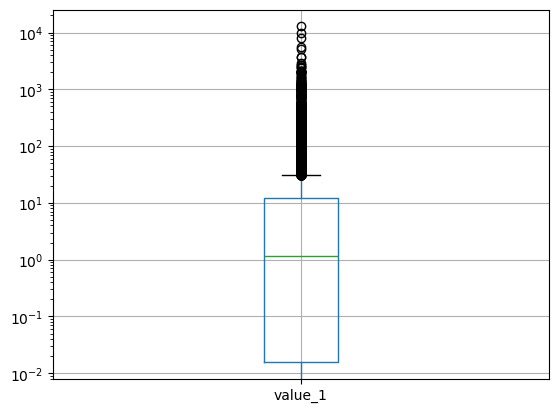

In [10]:
gene_pl.boxplot(column=['value_1'])
plt.yscale("log")
plt.show()

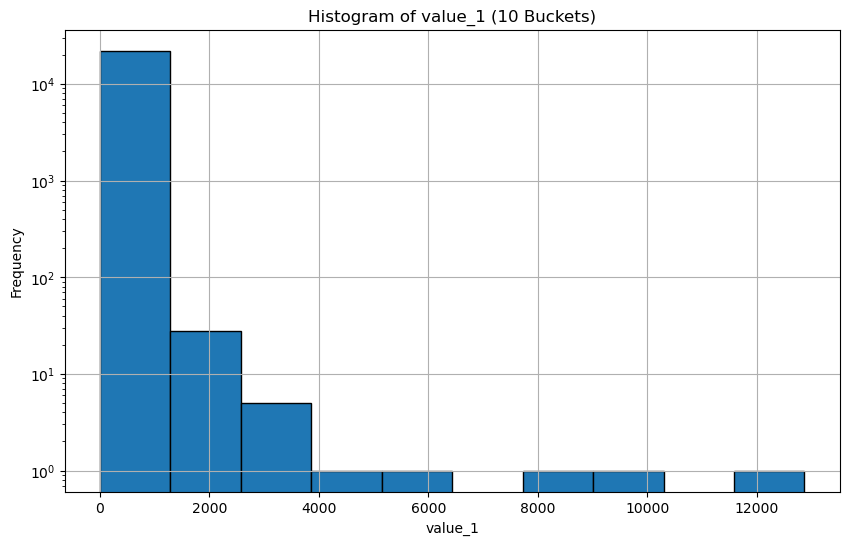

In [11]:
create_histogram(gene_pl, 'value_1', bins=10)

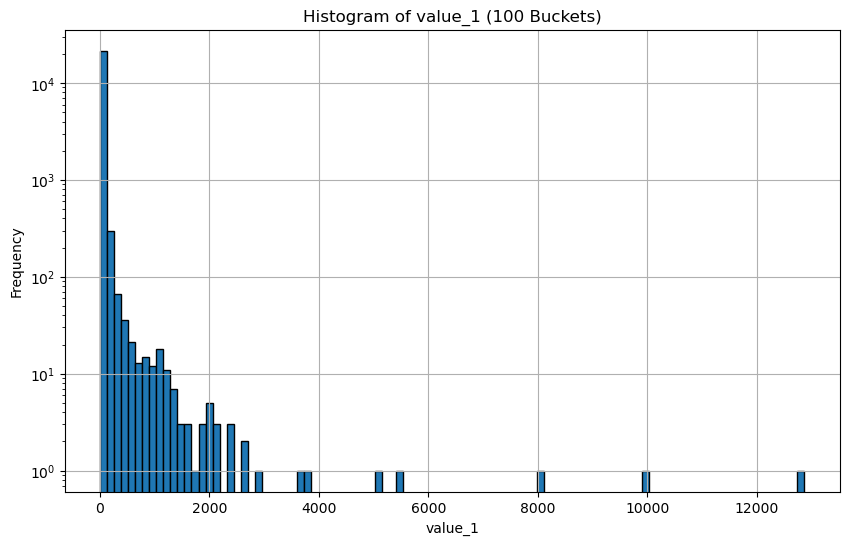

In [12]:
create_histogram(gene_pl, 'value_1', bins=100)

In [13]:
bucket_table_10 = create_bucket_table(gene_pl, 'value_1', 10)
bucket_table_100 = create_bucket_table(gene_pl, 'value_1', 100)

# Print the table
print(bucket_table_10)
print(bucket_table_100)

   Bucket Start  Bucket End  Frequency           Bucket Range
0          0.00     1287.09      22116       [0.00 - 1287.09)
1       1287.09     2574.18         28    [1287.09 - 2574.18)
2       2574.18     3861.27          5    [2574.18 - 3861.27)
3       3861.27     5148.36          1    [3861.27 - 5148.36)
4       5148.36     6435.45          1    [5148.36 - 6435.45)
5       6435.45     7722.54          0    [6435.45 - 7722.54)
6       7722.54     9009.63          1    [7722.54 - 9009.63)
7       9009.63    10296.72          1   [9009.63 - 10296.72)
8      10296.72    11583.81          0  [10296.72 - 11583.81)
9      11583.81    12870.90          1  [11583.81 - 12870.90)
    Bucket Start  Bucket End  Frequency           Bucket Range
0          0.000     128.709      21624        [0.00 - 128.71)
1        128.709     257.418        299      [128.71 - 257.42)
2        257.418     386.127         67      [257.42 - 386.13)
3        386.127     514.836         36      [386.13 - 514.84)
4  

In [14]:
markers = ['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']
X = reformat_data(gene_pl, markers)

In [15]:
y = gene_pl['value_1'].values

In [16]:
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [17]:
df_describe = pd.DataFrame(y_train)
df_describe.describe()

,0
count,17723.000000
mean,22.641261
std,179.643650
min,0.000000
25%,0.015389
50%,1.147240
75%,12.159500
max,12870.900000


In [18]:
df_describe = pd.DataFrame(y_test)
df_describe.describe()

,0
count,4431.000000
mean,18.719365
std,106.594038
min,0.000000
25%,0.016425
50%,1.121930
75%,12.568050
max,3781.020000


In [19]:
# Convert to DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [20]:
# XGBoost parameters
params = {
    'objective': 'reg:squarederror',
    'max_depth': 5,
    'learning_rate': 0.1,
}

In [21]:
# Train the model
model = xgb.train(
    params, 
    dtrain, 
    num_boost_round=100,
    evals=[(dtest, 'eval')],
    early_stopping_rounds=10
)

[0]	eval-rmse:106.94646
[1]	eval-rmse:108.02898
[2]	eval-rmse:109.94258
[3]	eval-rmse:112.27389
[4]	eval-rmse:115.43254
[5]	eval-rmse:118.53884
[6]	eval-rmse:121.76928
[7]	eval-rmse:125.59267
[8]	eval-rmse:129.16856
[9]	eval-rmse:132.62059
[10]	eval-rmse:136.33936


In [22]:
# Predict
y_pred = model.predict(dtest)

In [23]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

Model Evaluation Metrics:
MSE: 18588.4196
RMSE: 136.3394
MAE: 28.0415
R2: -0.6363


In [24]:
y_test_df = pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred
})

In [25]:
y_test_df = y_test_df.sort_values(by=['y_test'])
y_test_df = y_test_df.reset_index(drop=True)

In [26]:
y_test_df

,y_test,y_pred
0,0.00,13.946983
1,0.00,13.946983
2,0.00,13.946983
3,0.00,13.946983
4,0.00,13.946983
...,...,...
4426,1114.90,26.836613
4427,1167.97,36.784767
4428,2117.69,24.607943
4429,3731.54,16.863403


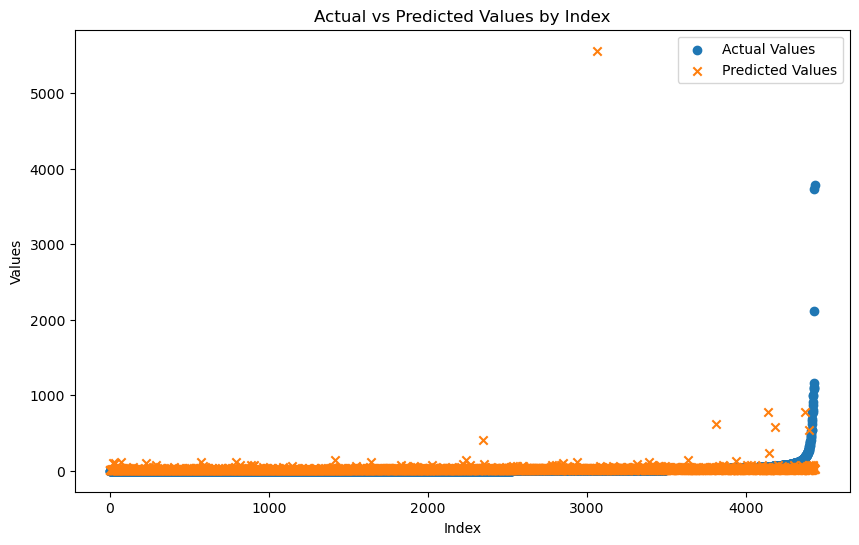

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_df.index, y_test_df['y_test'], label='Actual Values', marker='o')
plt.scatter(y_test_df.index, y_test_df['y_pred'], label='Predicted Values', marker='x')
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Actual vs Predicted Values by Index')
plt.legend()
plt.show()